# Q-Learning (Value-Based Optimization)

In [1]:
import numpy as np
import random

# Simple environment: 2 states, 2 actions
n_states = 2
n_actions = 2

# Initialize Q-table
Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.1       # learning rate
gamma = 0.9       # discount factor
n_episodes = 1000

# Simulated environment dynamics
def step(state, action):
    if state == 0 and action == 0:
        return 1, +1   # move to state 1, reward +1
    elif state == 0 and action == 1:
        return 0, 0    # stay in state 0, reward 0
    elif state == 1 and action == 0:
        return 1, +2   # stay in state 1, reward +2
    else:
        return 0, -1   # go back to state 0, reward -1

# Training loop
for episode in range(n_episodes):
    state = random.choice([0, 1])
    for _ in range(10):  # limit steps per episode
        action = np.argmax(Q[state]) if random.random() > 0.1 else random.choice([0,1])  # epsilon-greedy
        next_state, reward = step(state, action)
        
        # Q-learning update (optimization step)
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        
        state = next_state

print("Optimized Q-table:")
print(Q)


Optimized Q-table:
[[19.         16.84148842]
 [20.         16.1       ]]


# Policy Gradient (Policy-Based Optimization)

In [2]:
import numpy as np

# Simple 2-action bandit problem
n_actions = 2
theta = np.array([0.0, 0.0])  # policy parameters

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

# Reward function: action 0 gives reward 1, action 1 gives reward 2
def reward(action):
    return 1 if action == 0 else 2

alpha = 0.1  # learning rate

for episode in range(1000):
    probs = softmax(theta)
    action = np.random.choice(n_actions, p=probs)
    r = reward(action)
    
    # Policy gradient update
    grad_log_pi = np.zeros_like(theta)
    grad_log_pi[action] = 1 - probs[action]
    
    theta += alpha * r * grad_log_pi

print("Optimized policy parameters:", theta)
print("Final action probabilities:", softmax(theta))


Optimized policy parameters: [4.54185712 9.26787526]
Final action probabilities: [0.00878385 0.99121615]


# Training vs Validation Loss (Value-Based Methods)

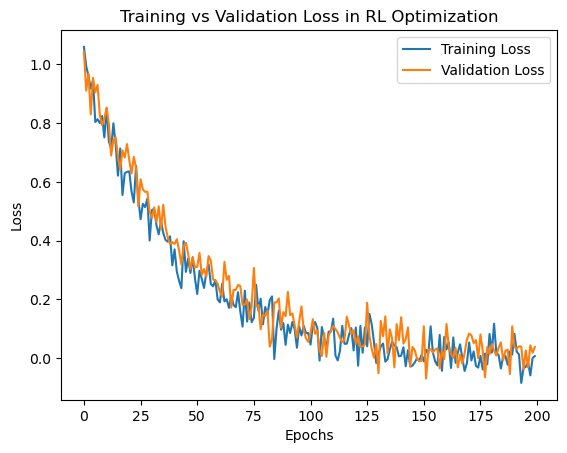

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated loss curves
epochs = np.arange(0, 200)
training_loss = np.exp(-epochs/40) + 0.05*np.random.randn(len(epochs))
validation_loss = np.exp(-epochs/45) + 0.05*np.random.randn(len(epochs))

plt.plot(epochs, training_loss, label="Training Loss")
plt.plot(epochs, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss in RL Optimization")
plt.legend()
plt.show()


# Average Reward per Episode (Policy-Based Methods)

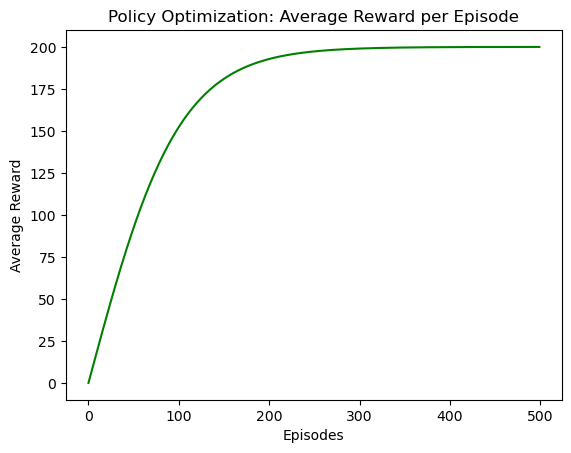

In [6]:
episodes = np.arange(0, 500)
avg_reward = np.tanh(episodes/100) * 200  # simulated reward growth

plt.plot(episodes, avg_reward, color="green")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Policy Optimization: Average Reward per Episode")
plt.show()


# Trust Region Policy Optimization (TRPO)

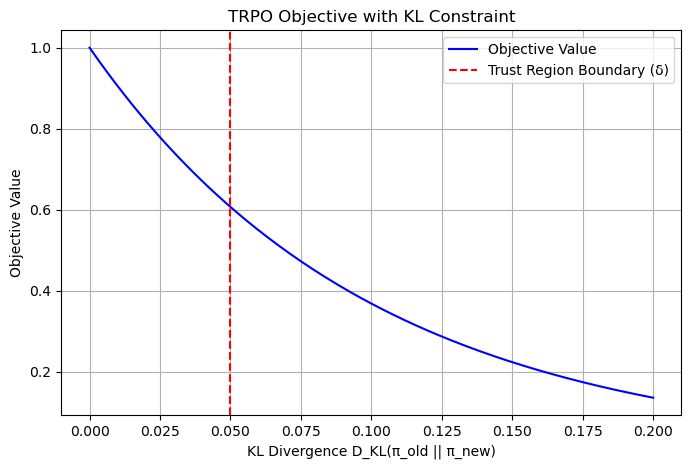

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated KL divergences between old and new policy
kl_divs = np.linspace(0, 0.2, 200)

# Simulated objective values (advantage * ratio)
# For illustration, assume objective decreases as KL grows
objective = np.exp(-10 * kl_divs)  # just a toy curve

# Trust region threshold
delta = 0.05

plt.figure(figsize=(8,5))
plt.plot(kl_divs, objective, label="Objective Value", color="blue")
plt.axvline(delta, color="red", linestyle="--", label="Trust Region Boundary (δ)")
plt.xlabel("KL Divergence D_KL(π_old || π_new)")
plt.ylabel("Objective Value")
plt.title("TRPO Objective with KL Constraint")
plt.legend()
plt.grid(True)
plt.show()


# Probability Ratio Clipping (PPO)

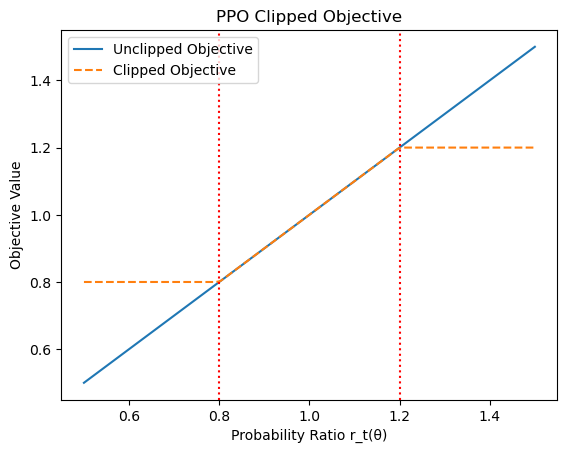

In [9]:
ratios = np.linspace(0.5, 1.5, 100)
advantage = 1.0
epsilon = 0.2

unclipped = ratios * advantage
clipped = np.clip(ratios, 1-epsilon, 1+epsilon) * advantage

plt.plot(ratios, unclipped, label="Unclipped Objective")
plt.plot(ratios, clipped, label="Clipped Objective", linestyle="--")
plt.axvline(1-epsilon, color="red", linestyle=":")
plt.axvline(1+epsilon, color="red", linestyle=":")
plt.xlabel("Probability Ratio r_t(θ)")
plt.ylabel("Objective Value")
plt.title("PPO Clipped Objective")
plt.legend()
plt.show()
